# День 3 — Attention-матрицы и визуализация

**Цель дня:** понять, как работает механизм внимания в трансформерах, и научиться его визуализировать.

Используем код из Дней 1–2. Переиспользуемые функции этого дня — в [`attention_utils.py`](attention_utils.py).

In [1]:
# !pip install matplotlib seaborn

from transformers import AutoTokenizer, AutoModel
import torch

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

C:\Users\Vsevolod\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Задача 1: Загрузка модели с attention

Флаг `output_attentions=True` обязателен — без него `outputs.attentions` будет `None`.

In [2]:
model = AutoModel.from_pretrained(
    model_name,
    output_attentions=True,  # важно!
)
model.eval()

text = "The amazing movie won many awards"
tokens = tokenizer(text, return_tensors="pt")
print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7579.57it/s]


[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['[CLS]', 'the', 'amazing', 'movie', 'won', 'many', 'awards', '[SEP]']


## Задача 2: Получение attention весов

In [3]:
with torch.no_grad():
    outputs = model(**tokens)

print(type(outputs.attentions))
print(f'Количество слоёв: {len(outputs.attentions)}')
print(f'Форма attention для слоя 0: {outputs.attentions[0].shape}')

<class 'tuple'>
Количество слоёв: 6
Форма attention для слоя 0: torch.Size([1, 12, 8, 8])


Форма: `[batch_size, num_heads, seq_len, seq_len]`.

In [4]:
attention = outputs.attentions[0]  # первый слой
print(f'Attention shape: {attention.shape}')

# Для первого батча, первой головы
attn_single = attention[0, 0]  # [seq_len, seq_len]
print(f'Single head shape: {attn_single.shape}')

# Каждая строка — распределение (softmax), сумма = 1
print(f'Сумма по строке: {attn_single[0].sum():.4f}')

Attention shape: torch.Size([1, 12, 8, 8])
Single head shape: torch.Size([8, 8])
Сумма по строке: 1.0000


## Задача 3: Визуализация attention

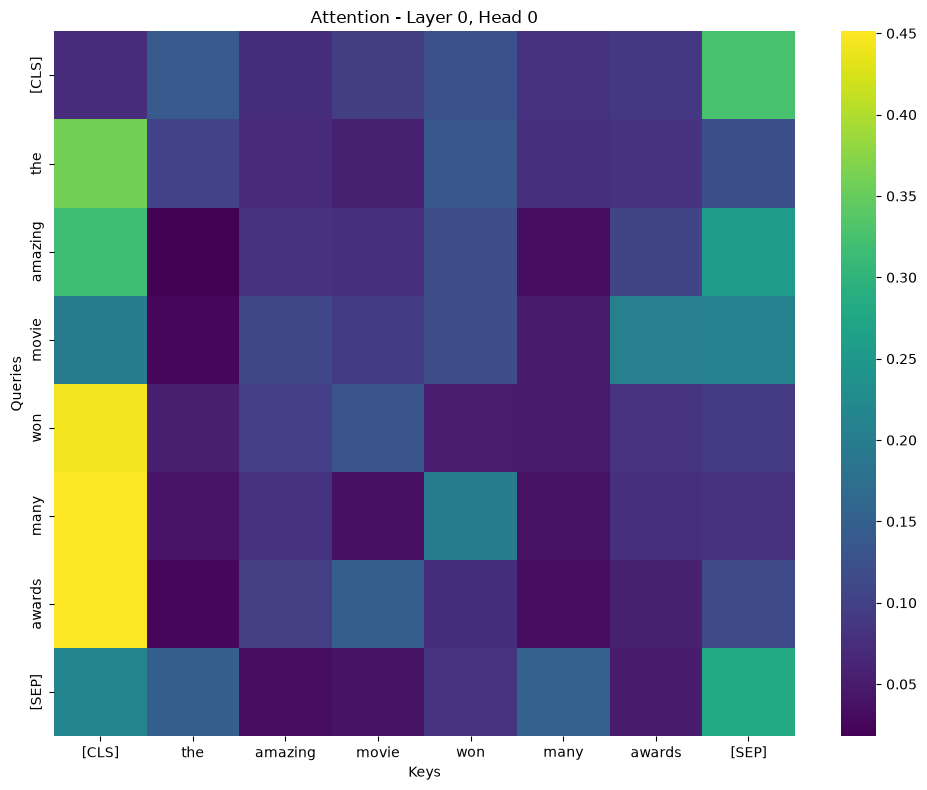

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def visualize_attention(tokens, attention, layer=0, head=0):
    """
    tokens: токенизированный текст
    attention: attention weights от модели
    layer: номер слоя для визуализации
    head: номер головы для визуализации
    """
    # Получаем attention матрицу
    attn = attention[layer][0, head]  # [seq_len, seq_len]

    # Получаем токены для подписей
    token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

    # Рисуем heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn.cpu().numpy(),
        xticklabels=token_list,
        yticklabels=token_list,
        cmap='viridis',
        cbar=True,
    )
    plt.title(f'Attention - Layer {layer}, Head {head}')
    plt.xlabel('Keys')
    plt.ylabel('Queries')
    plt.tight_layout()
    plt.savefig(f'attention_layer{layer}_head{head}.png')
    plt.show()


visualize_attention(tokens, outputs.attentions, layer=0, head=0)

Как читать матрицу: строка — токен-**запрос** (Query, «кто смотрит»), столбец — токен-**ключ** (Key, «на кого смотрят»). Яркая ячейка `(i, j)` = токен `i` сильно внимает токену `j`. Каждая строка суммируется в 1.

## Задача 4: Анализ attention для разных слоёв

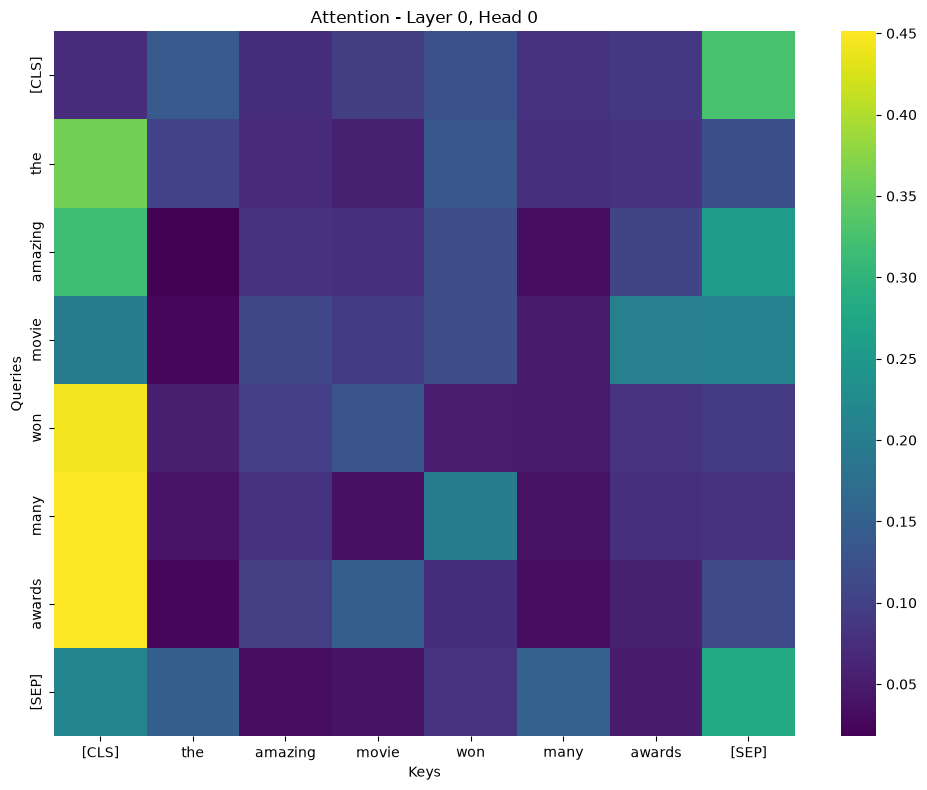

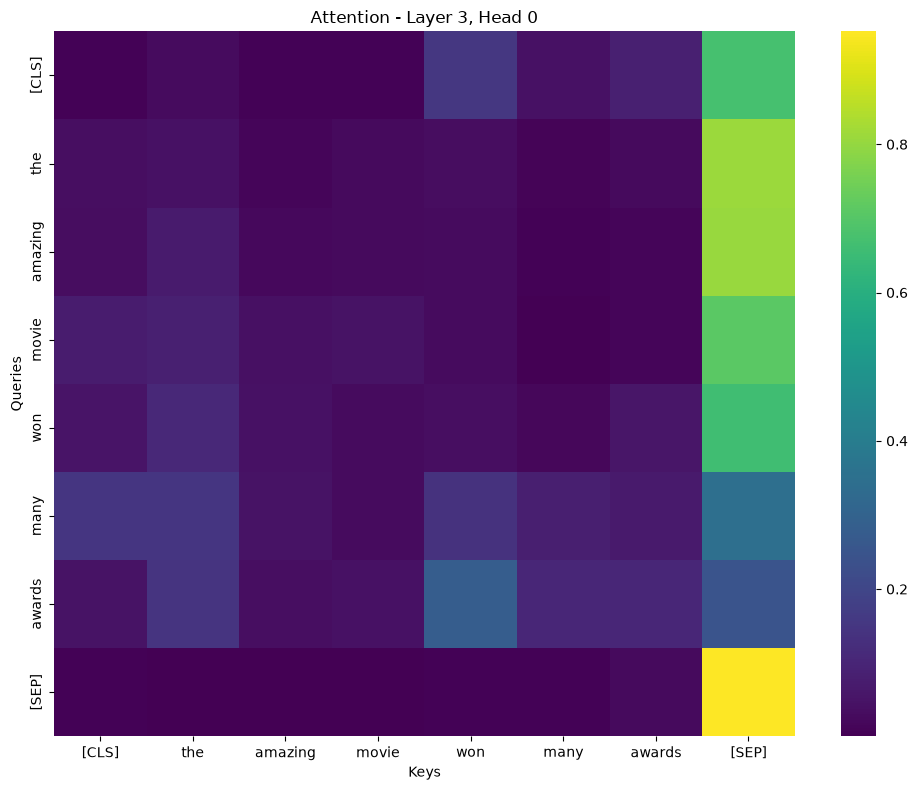

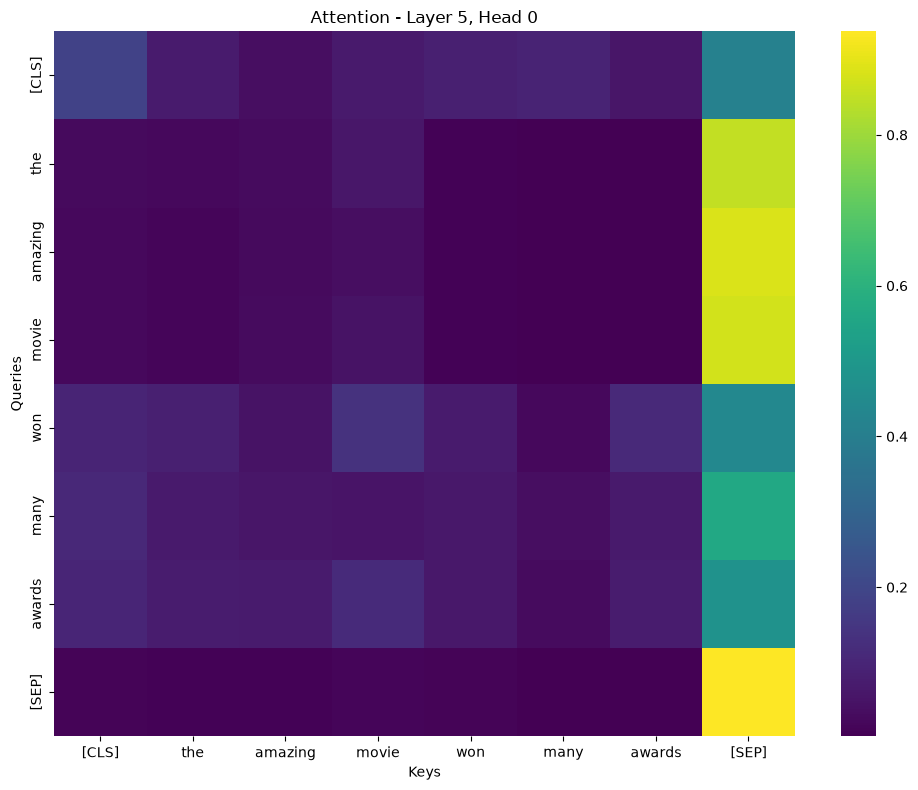

In [6]:
# Первый слой
visualize_attention(tokens, outputs.attentions, layer=0, head=0)

# Средний слой
visualize_attention(tokens, outputs.attentions, layer=3, head=0)

# Последний слой
visualize_attention(tokens, outputs.attentions, layer=5, head=0)

**Наблюдение.** На ранних слоях внимание более «размазано» по соседним токенам, на поздних — сильно концентрируется на служебных токенах `[CLS]` и особенно `[SEP]`.

Это известный эффект — *attention sink*: когда голове «нечего сказать» на данном шаге, она сбрасывает вес на разделительный токен, потому что softmax обязан распределить суммарный вес 1. Так что яркая полоса на `[SEP]` — это не «модель считает [SEP] самым важным словом», а скорее «эта голова здесь неактивна».

## Задача 5: Attention для разных голов

Число голов берём из самой модели (для DistilBERT это 12). Чтобы не плодить 12 отдельных картинок, показываем их одной сеткой — так удобнее сравнивать.

Число голов: 12


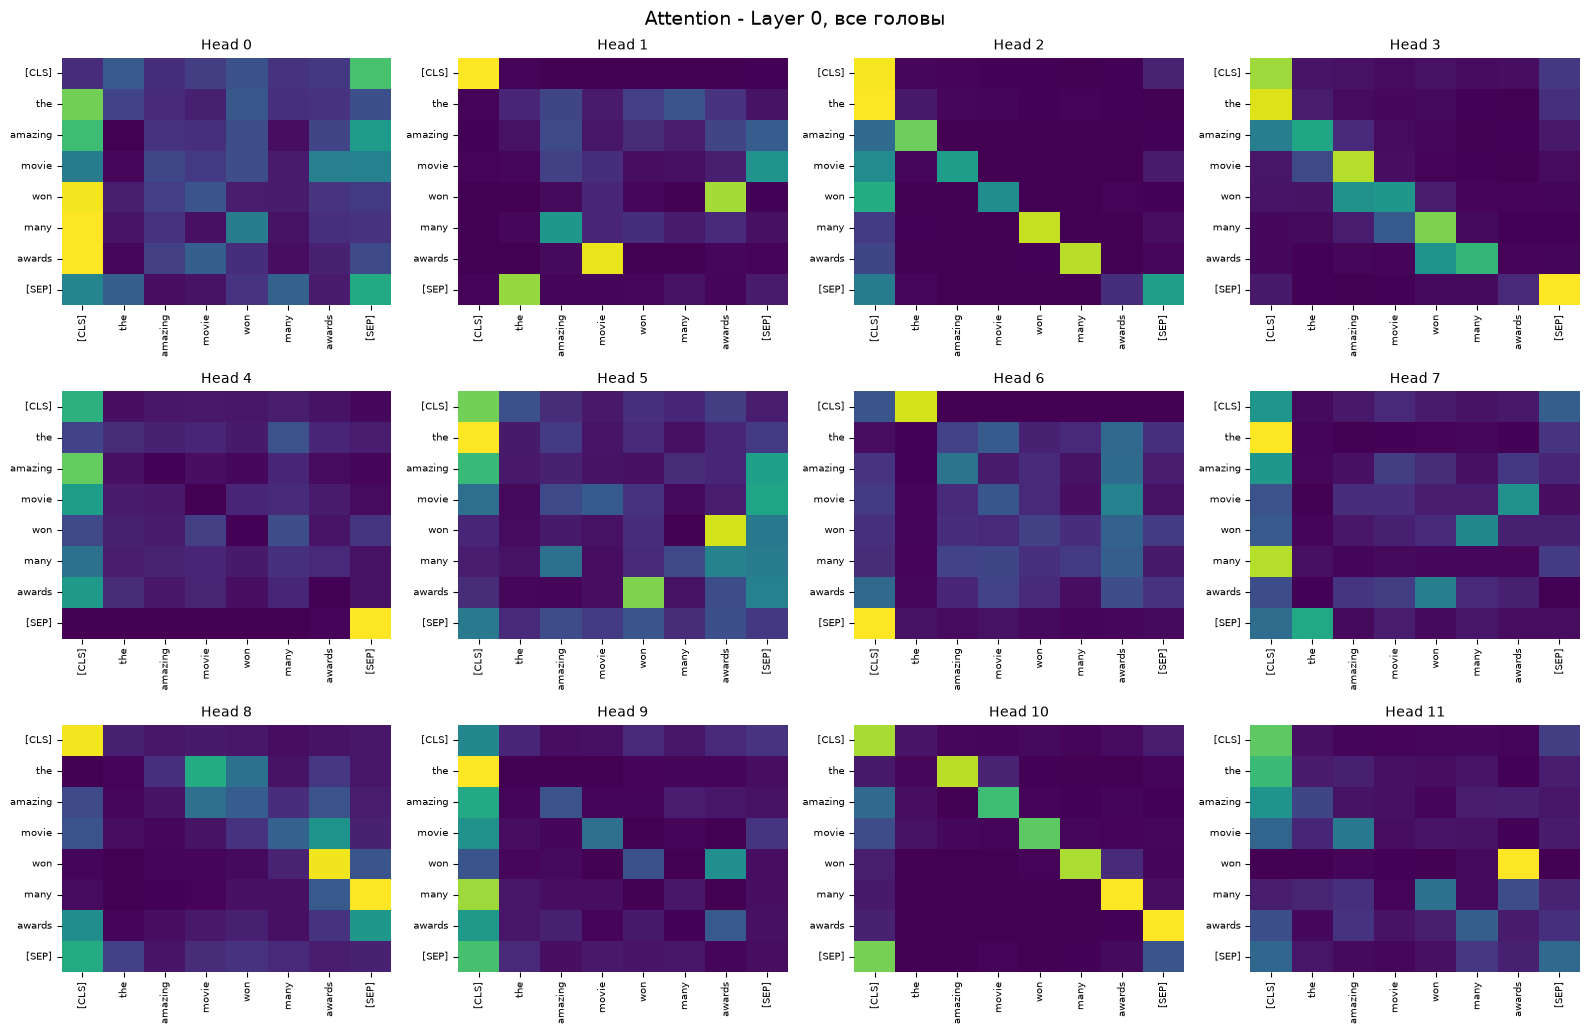

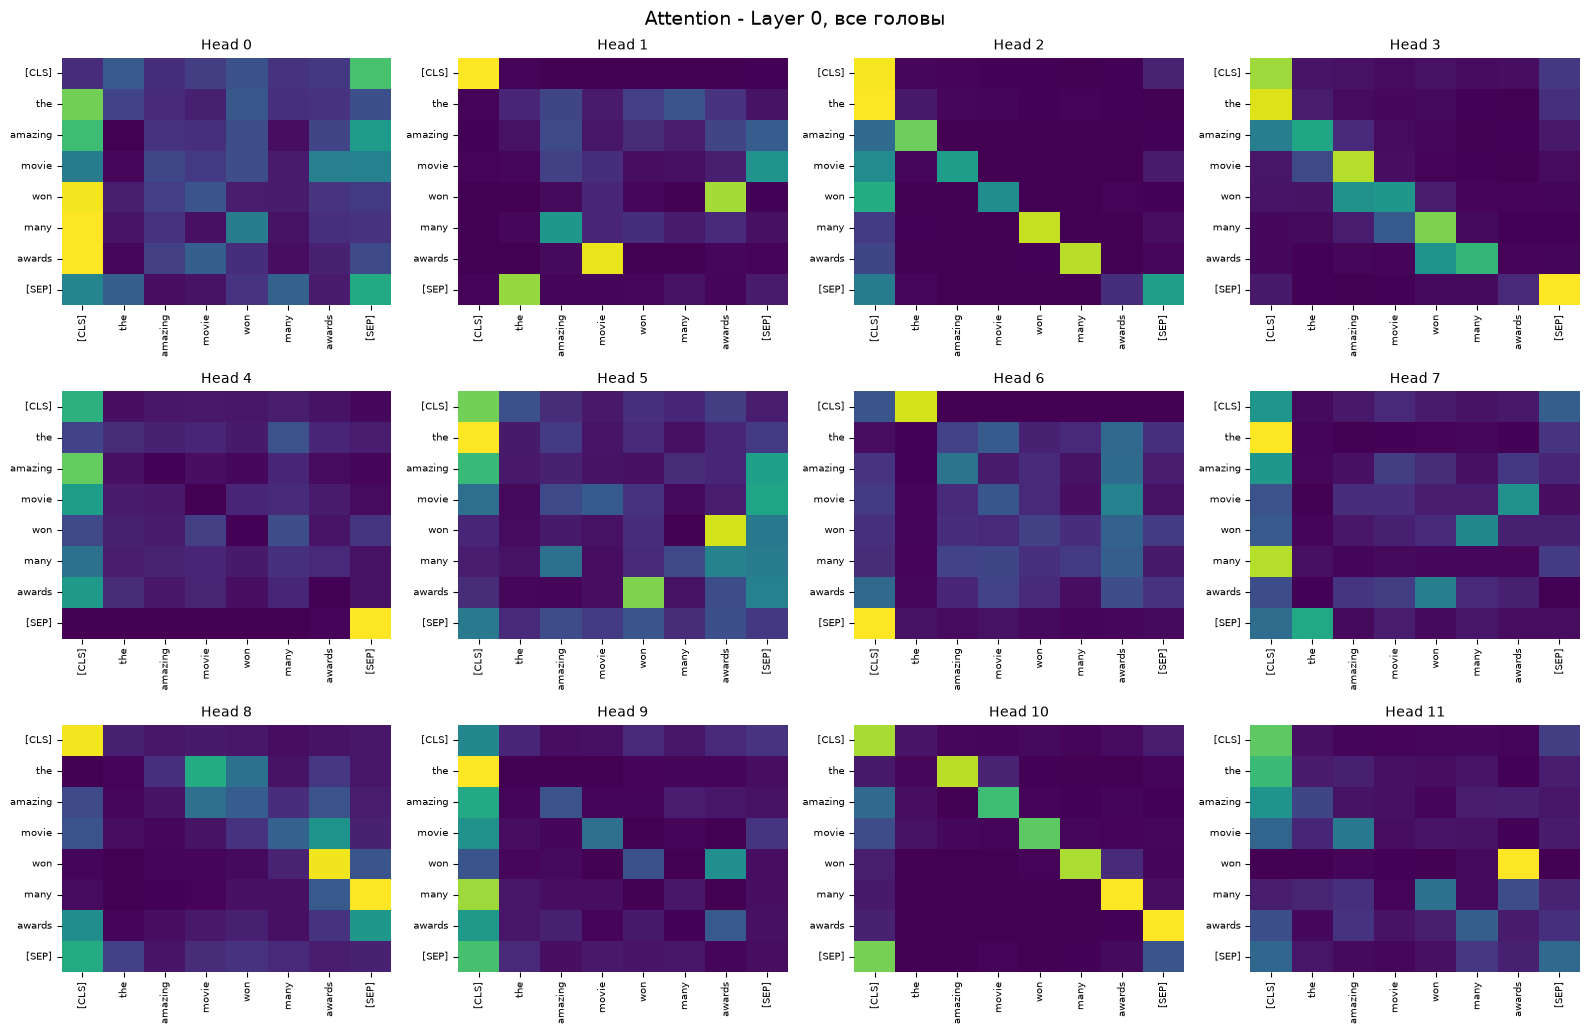

In [7]:
from attention_utils import visualize_all_heads

num_heads = outputs.attentions[0].shape[1]
print(f'Число голов: {num_heads}')

visualize_all_heads(tokens, outputs.attentions, tokenizer, layer=0)

**Наблюдение.** Головы явно специализируются и выглядят по-разному:
- некоторые дают диагональ — токен смотрит сам на себя;
- некоторые дают поддиагональ/наддиагональ — внимание к соседу слева или справа (локальный контекст);
- некоторые дают вертикальную полосу — все токены смотрят на один служебный токен (тот самый attention sink).

Если нужно посмотреть отдельную голову крупно — используйте `visualize_attention(...)` с нужным `head`.

## Задача 6: Анализ внимания к ключевым словам

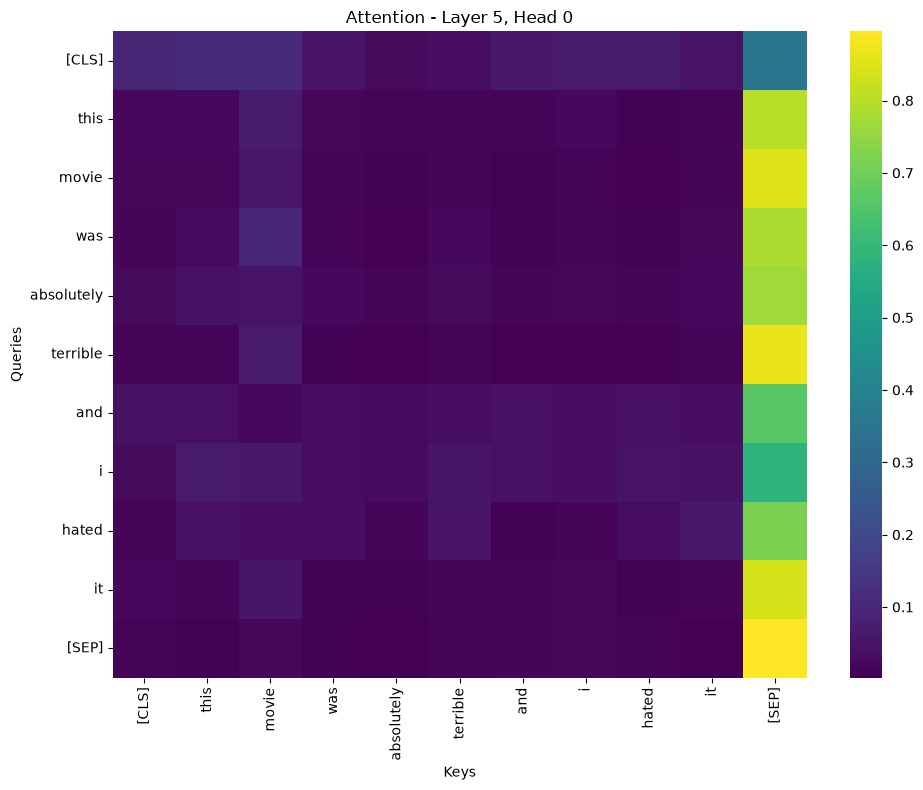

In [8]:
text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)

visualize_attention(tokens, outputs.attentions, layer=5, head=0)

Чтобы ответить на вопрос «на что смотрит слово *terrible*» численно, а не на глаз, усредним внимание по всем головам последнего слоя и посмотрим топ ключей для строки `terrible`.

In [9]:
from attention_utils import attention_to_word

print("Внимание слова 'terrible' (последний слой, среднее по головам):")
for tok, weight in attention_to_word(tokens, outputs.attentions, tokenizer, 'terrible', layer=-1):
    print(f'  {tok:12s} {weight:.3f}')

print("\nДля сравнения — первый слой:")
for tok, weight in attention_to_word(tokens, outputs.attentions, tokenizer, 'terrible', layer=0):
    print(f'  {tok:12s} {weight:.3f}')

Внимание слова 'terrible' (последний слой, среднее по головам):
  [SEP]        0.651
  terrible     0.069
  this         0.044
  movie        0.041
  was          0.037

Для сравнения — первый слой:
  [CLS]        0.223
  absolutely   0.223
  [SEP]        0.102
  and          0.101
  hated        0.071


**Вывод.** На последнем слое основной вес уходит на `[SEP]` (attention sink), а среди содержательных слов — на само `terrible` и ближайший контекст. На первом слое картина «честнее»: внимание распределено по соседним словам предложения.

Важно не переинтерпретировать эти картинки: высокий attention-вес ≠ «это слово важно для предсказания». Это активная дискуссия в литературе (*Attention is not Explanation*). Attention показывает, откуда берётся информация при смешивании представлений, а не итоговую значимость признака.

## Чекпоинт

К концу дня есть:
- ✅ Модель, загруженная с `output_attentions=True`
- ✅ Понимание формы attention: `[batch, num_heads, seq_len, seq_len]`, 6 слоёв × 12 голов
- ✅ Функция `visualize_attention` (heatmap одной головы) + `visualize_all_heads` (сетка)
- ✅ Функция `attention_to_word` для численного анализа внимания к слову

Переиспользуемый код — в [`attention_utils.py`](attention_utils.py).